In [1]:
import pandas as pd
import yfinance as yf

df=yf.download(start='2015-01-01', end='2025-12-31', tickers='AAPL')


[*********************100%***********************]  1 of 1 completed


In [2]:
# Flatten the MultiIndex columns
df.columns = df.columns.get_level_values(0)

print(df.columns)
print(df.head())

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
Price           Close       High        Low       Open     Volume
Date                                                             
2015-01-02  24.192604  24.659506  23.754468  24.648441  212818400
2015-01-05  23.511063  24.042136  23.325188  23.962475  257142000
2015-01-06  23.513268  23.772165  23.152579  23.575226  263188400
2015-01-07  23.842983  23.942559  23.610638  23.721278  160423600
2015-01-08  24.759075  24.816609  24.053190  24.170470  237458000


In [3]:
# Quick inspection
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())

(2765, 5)
Price           Close       High        Low       Open     Volume
Date                                                             
2015-01-02  24.192604  24.659506  23.754468  24.648441  212818400
2015-01-05  23.511063  24.042136  23.325188  23.962475  257142000
2015-01-06  23.513268  23.772165  23.152579  23.575226  263188400
2015-01-07  23.842983  23.942559  23.610638  23.721278  160423600
2015-01-08  24.759075  24.816609  24.053190  24.170470  237458000
<class 'pandas.DataFrame'>
DatetimeIndex: 2765 entries, 2015-01-02 to 2025-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2765 non-null   float64
 1   High    2765 non-null   float64
 2   Low     2765 non-null   float64
 3   Open    2765 non-null   float64
 4   Volume  2765 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 129.6 KB
None
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [4]:
df.shape

(2765, 5)

In [5]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,24.192604,24.659506,23.754468,24.648441,212818400
2015-01-05,23.511063,24.042136,23.325188,23.962475,257142000
2015-01-06,23.513268,23.772165,23.152579,23.575226,263188400
2015-01-07,23.842983,23.942559,23.610638,23.721278,160423600
2015-01-08,24.759075,24.816609,24.053190,24.170470,237458000


In [6]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2765 entries, 2015-01-02 to 2025-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2765 non-null   float64
 1   High    2765 non-null   float64
 2   Low     2765 non-null   float64
 3   Open    2765 non-null   float64
 4   Volume  2765 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 129.6 KB


In [7]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2765 entries, 2015-01-02 to 2025-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2765 non-null   float64
 1   High    2765 non-null   float64
 2   Low     2765 non-null   float64
 3   Open    2765 non-null   float64
 4   Volume  2765 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 129.6 KB


In [8]:
df.isnull().sum()

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

# EDA

In [9]:
pip install ta

Note: you may need to restart the kernel to use updated packages.


In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from ta.trend import EMAIndicator, MACD
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands
import seaborn as sns

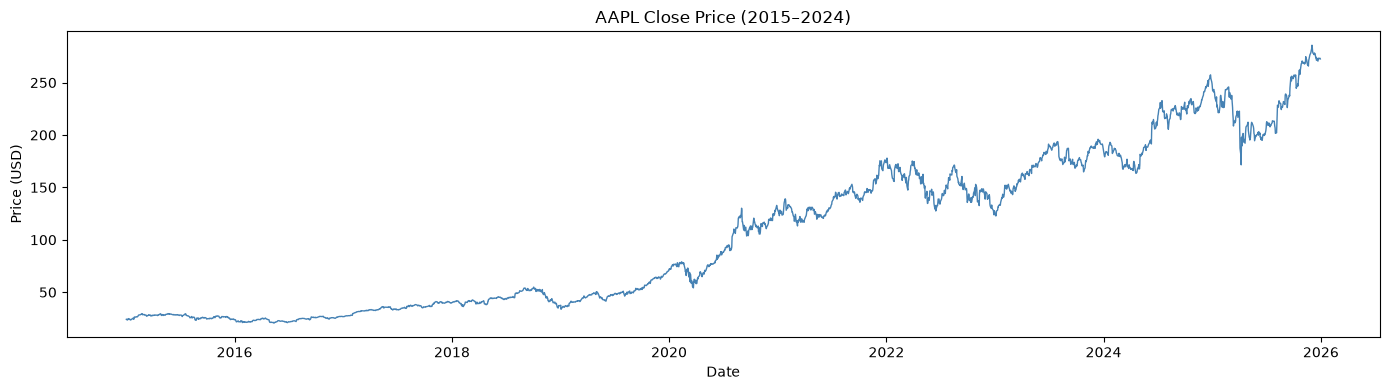

In [11]:
# Plot Close Price 
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['Close'], color='steelblue', linewidth=1)
plt.title('AAPL Close Price (2015–2024)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

In [12]:
# Technical Indicators
# EMA
df['EMA_20'] = EMAIndicator(df['Close'], window=20).ema_indicator()
df['EMA_50'] = EMAIndicator(df['Close'], window=50).ema_indicator()

# RSI
df['RSI_14'] = RSIIndicator(df['Close'], window=14).rsi()

# MACD
macd = MACD(df['Close'])
df['MACD']        = macd.macd()
df['MACD_Signal'] = macd.macd_signal()

# Bollinger Bands
bb = BollingerBands(df['Close'], window=20)
df['BB_High'] = bb.bollinger_hband()
df['BB_Low']  = bb.bollinger_lband()

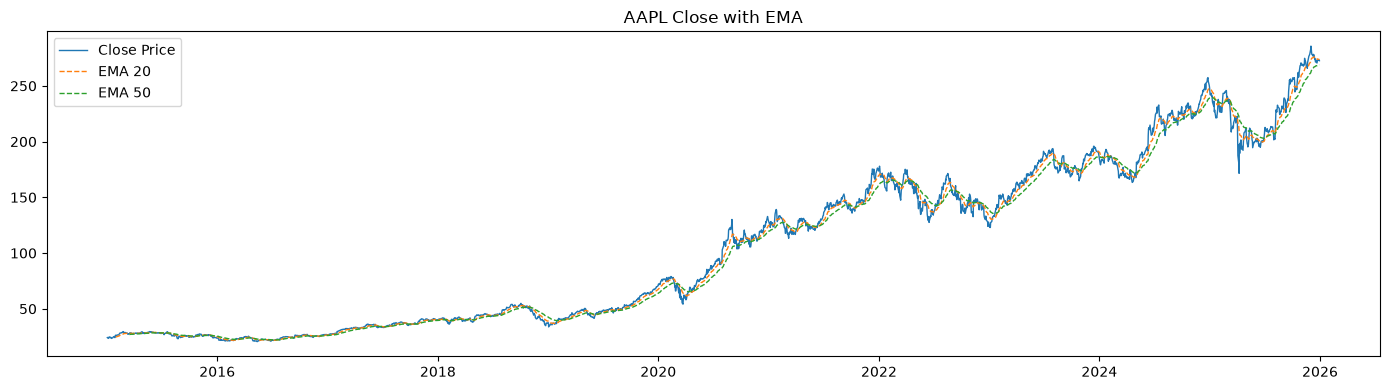

In [13]:
# Plot EMA
plt.figure(figsize=(14, 4))
plt.plot(df['Close'], label='Close Price', linewidth=1)
plt.plot(df['EMA_20'], label='EMA 20', linewidth=1, linestyle='--')
plt.plot(df['EMA_50'], label='EMA 50', linewidth=1, linestyle='--')
plt.title('AAPL Close with EMA')
plt.legend()
plt.tight_layout()
plt.show()


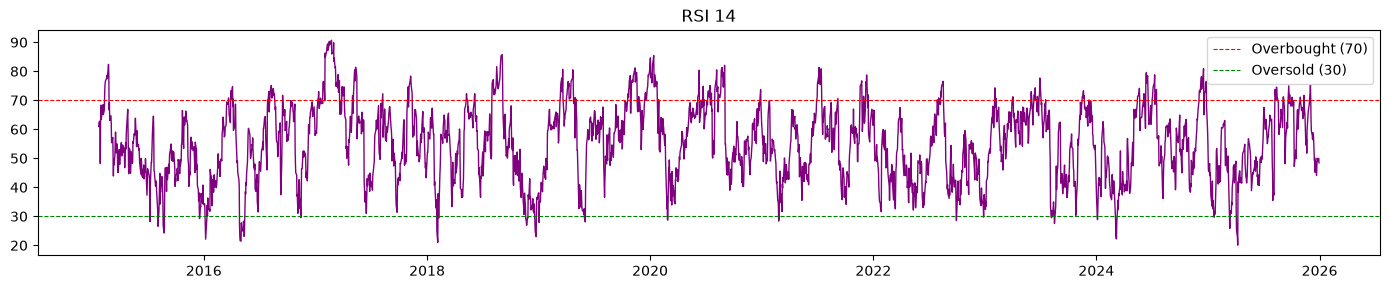

In [14]:
#  Plot RSI
plt.figure(figsize=(14, 3))
plt.plot(df['RSI_14'], color='purple', linewidth=1)
plt.axhline(70, color='red',   linestyle='--', linewidth=0.8, label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', linewidth=0.8, label='Oversold (30)')
plt.title('RSI 14')
plt.legend()
plt.tight_layout()
plt.show()

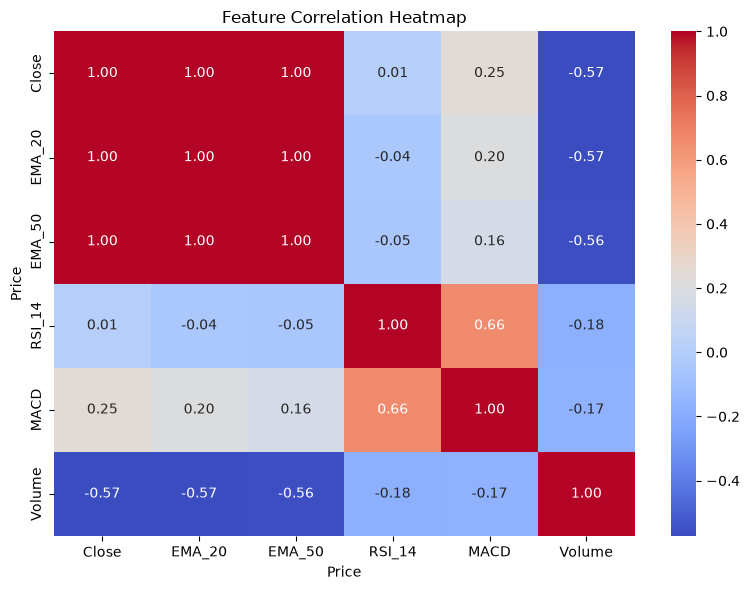

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[['Close','EMA_20','EMA_50','RSI_14','MACD','Volume']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm'
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [16]:
df.isna().sum()

Price
Close           0
High            0
Low             0
Open            0
Volume          0
EMA_20         19
EMA_50         49
RSI_14         13
MACD           25
MACD_Signal    33
BB_High        19
BB_Low         19
dtype: int64

In [17]:
df.dropna(inplace=True)
print(f"Final shape after dropping NaNs: {df.shape}")
df.head()

Final shape after dropping NaNs: (2716, 12)


Price,Close,High,Low,Open,Volume,EMA_20,EMA_50,RSI_14,MACD,MACD_Signal,BB_High,BB_Low
Date,,,,,,,,,,,,
2015-03-16,27.758127,27.758127,27.296048,27.520423,143497200,27.853933,26.928278,51.177490,0.215346,0.469618,29.570625,27.172361
2015-03-17,28.222431,28.284634,27.913637,27.969176,204092400,27.889028,26.979029,56.042688,0.224620,0.420618,29.563515,27.161920
2015-03-18,28.540108,28.693394,28.073585,28.213541,261083600,27.951035,27.040248,59.049505,0.254668,0.387428,29.558826,27.161056
2015-03-19,28.324614,28.713383,28.302399,28.602306,183238000,27.986614,27.090615,56.239221,0.258117,0.361566,29.545614,27.153164
2015-03-20,27.969175,28.524558,27.804782,28.491237,274780400,27.984953,27.125069,51.855508,0.229524,0.335158,29.500311,27.118491


In [18]:
df.drop(columns=['EMA_20', 'EMA_50'], inplace=True)
df.head()

Price,Close,High,Low,Open,Volume,RSI_14,MACD,MACD_Signal,BB_High,BB_Low
Date,,,,,,,,,,
2015-03-16,27.758127,27.758127,27.296048,27.520423,143497200,51.177490,0.215346,0.469618,29.570625,27.172361
2015-03-17,28.222431,28.284634,27.913637,27.969176,204092400,56.042688,0.224620,0.420618,29.563515,27.161920
2015-03-18,28.540108,28.693394,28.073585,28.213541,261083600,59.049505,0.254668,0.387428,29.558826,27.161056
2015-03-19,28.324614,28.713383,28.302399,28.602306,183238000,56.239221,0.258117,0.361566,29.545614,27.153164
2015-03-20,27.969175,28.524558,27.804782,28.491237,274780400,51.855508,0.229524,0.335158,29.500311,27.118491


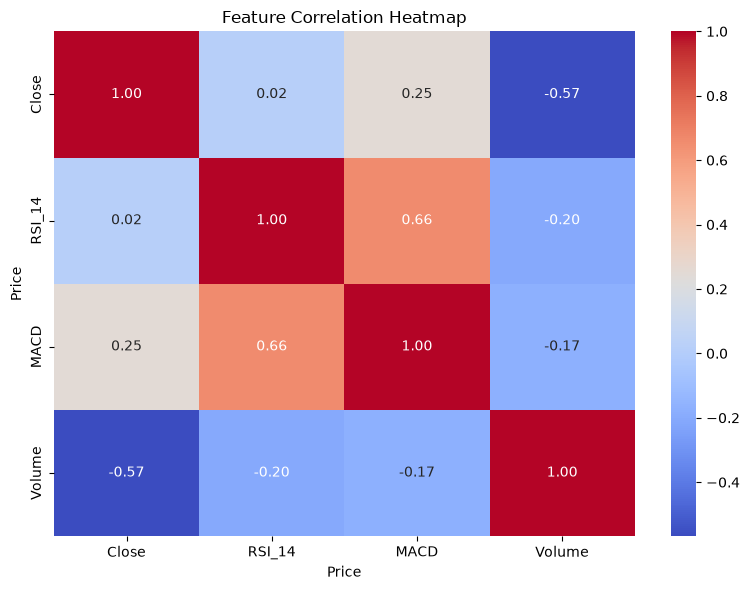

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[['Close','RSI_14','MACD','Volume']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm'
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [20]:
# Preprocessing for modeling
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

In [21]:
features = ['Close', 'High', 'Low', 'Open', 'Volume', 'RSI_14', 'MACD', 'MACD_Signal', 'BB_High', 'BB_Low']
target   = 'Close'

data=df[features].values

In [22]:
data

array([[ 27.75812721,  27.75812721,  27.29604842, ...,   0.46961776,
         29.57062503,  27.17236051],
       [ 28.22243118,  28.284634  ,  27.9136374 , ...,   0.42061825,
         29.56351506,  27.16192039],
       [ 28.54010773,  28.69339444,  28.07358494, ...,   0.38742824,
         29.55882636,  27.16105566],
       ...,
       [272.89300537, 274.85935345, 272.35399821, ...,   1.19658359,
        284.84903103, 268.01279758],
       [273.25234985, 273.85121285, 271.8449609 , ...,   0.99112101,
        284.656494  , 267.69728103],
       [272.57354736, 273.57169282, 271.77504318, ...,   0.808691  ,
        283.75846294, 267.5951656 ]], shape=(2716, 10))

In [23]:
scaler=MinMaxScaler()

train_size=int(len(data)*0.7)
val_size=int(len(data)*0.15)

train_data=data[:train_size]
val_data=data[train_size:train_size+val_size]
test_data=data[train_size+val_size:]

In [24]:
scaler.fit(train_data)
train_scaled=scaler.transform(train_data)
val_scaled=scaler.transform(val_data)
test_scaled=scaler.transform(test_data)

In [25]:
LOOKBACK = 60  # use last 60 days to predict next day

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])       # 60 timesteps, all features
        y.append(data[i, 0])               # index 0 = Close (target)
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, LOOKBACK)
X_val,   y_val   = create_sequences(val_scaled,   LOOKBACK)
X_test,  y_test  = create_sequences(test_scaled,  LOOKBACK)

In [26]:
print(f"X_train: {X_train.shape}")  # (samples, 60, 10)
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")  # (samples,)

X_train: (1841, 60, 10)
X_val:   (347, 60, 10)
X_test:  (348, 60, 10)
y_train: (1841,)


In [27]:
# Model building and Training
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [28]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

In [29]:
# Model1
model1=Sequential([
    SimpleRNN(64, input_shape=(60, 10), return_sequences=False),
    Dropout(0.2),
    Dense(1)  # Output layer for regression
])
model1.compile(optimizer='adam', loss='mse')
history1=model1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100


c:\Users\ASUS\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0753 - val_loss: 0.0116 - learning_rate: 0.0010
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0195 - val_loss: 0.0034 - learning_rate: 0.0010
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0131 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0098 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0079 - val_loss: 6.6699e-04 - learning_rate: 0.0010
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0061 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0064 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 8/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0054 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 9/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0046 - val_loss: 7.8639e-04 - learning_rate: 0.0010
Epoch 10/100
58/58 ━━━━

In [30]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,597 (57.02 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,732 (38.02 KB)

In [33]:
X_train.shape

(1841, 60, 10)

In [32]:
model2 = Sequential([
    LSTM(64, input_shape=(60, 10), return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model2.compile(optimizer='adam', loss='mse')
model2.summary()

history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

c:\Users\ASUS\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 60, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 60, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,673 (252.63 KB)

 Trainable params: 64,673 (252.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - loss: 0.0112 - val_loss: 0.0095 - learning_rate: 0.0010
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0037 - val_loss: 0.0048 - learning_rate: 0.0010
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0036 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - loss: 0.0031 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0029
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - loss: 0.0028 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0026 - val_loss: 0.0017 - learning_rate: 5.0000e-04
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0028 - val_loss: 0.0029 - learning_rate: 5.0000e-04
Epoch 8/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0025 - val_loss: 0.0049 - lea

In [37]:
# model3
model3=Sequential([
    LSTM(128, input_shape=(60, 10), return_sequences=True),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model3.compile(optimizer='adam', loss='mse')
model3.summary()

history3 = model3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

c:\Users\ASUS\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_13 (LSTM)                  │ (None, 60, 128)        │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,537 (521.63 KB)

 Trainable params: 133,537 (521.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - loss: 0.0111 - val_loss: 0.0032 - learning_rate: 0.0010
Epoch 2/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0037 - val_loss: 0.0028 - learning_rate: 0.0010
Epoch 3/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0026 - val_loss: 0.0061 - learning_rate: 0.0010
Epoch 4/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0026 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 5/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0024
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - loss: 0.0025 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 6/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - loss: 0.0021 - val_loss: 0.0095 - learning_rate: 5.0000e-04
Epoch 7/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 0.0019 - val_loss: 0.0040 - learning_rate: 5.0000e-04
Epoch 8/100
58/58 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 0.0020 - val_loss: 0.0067 - lea

In [41]:
# Evaluation and Visualization
pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)
pred3 = model3.predict(X_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [42]:
pred1

array([[1.1569777 ],
       [1.1965919 ],
       [1.2025907 ],
       [1.1975126 ],
       [1.2033896 ],
       [1.2087872 ],
       [1.2176502 ],
       [1.234324  ],
       [1.2392898 ],
       [1.2441583 ],
       [1.2468889 ],
       [1.245832  ],
       [1.2336204 ],
       [1.2324958 ],
       [1.2442074 ],
       [1.2457659 ],
       [1.2399125 ],
       [1.2419677 ],
       [1.2356997 ],
       [1.2237582 ],
       [1.2188401 ],
       [1.2094982 ],
       [1.2120793 ],
       [1.2050552 ],
       [1.2172999 ],
       [1.2048488 ],
       [1.2053931 ],
       [1.2120705 ],
       [1.2144265 ],
       [1.2284973 ],
       [1.2541571 ],
       [1.2586148 ],
       [1.2539287 ],
       [1.2197013 ],
       [1.2439866 ],
       [1.2508519 ],
       [1.2578712 ],
       [1.2493865 ],
       [1.2389283 ],
       [1.2319474 ],
       [1.2308252 ],
       [1.2341619 ],
       [1.2455769 ],
       [1.2352808 ],
       [1.2419977 ],
       [1.2462251 ],
       [1.2618382 ],
       [1.262

In [43]:
pred2

array([[1.0232264 ],
       [1.0213183 ],
       [1.0197848 ],
       [1.0187291 ],
       [1.0182077 ],
       [1.0182105 ],
       [1.0186852 ],
       [1.0195898 ],
       [1.0208327 ],
       [1.0223435 ],
       [1.0239381 ],
       [1.0255574 ],
       [1.0271586 ],
       [1.0287945 ],
       [1.0304085 ],
       [1.0319718 ],
       [1.0335023 ],
       [1.0347322 ],
       [1.0356814 ],
       [1.0363594 ],
       [1.0366293 ],
       [1.0365671 ],
       [1.0362235 ],
       [1.0357654 ],
       [1.0353175 ],
       [1.0347716 ],
       [1.0340412 ],
       [1.0331397 ],
       [1.0322663 ],
       [1.0314089 ],
       [1.0308269 ],
       [1.0306119 ],
       [1.0307363 ],
       [1.031187  ],
       [1.0319402 ],
       [1.0328877 ],
       [1.0340513 ],
       [1.0352217 ],
       [1.0363493 ],
       [1.0373722 ],
       [1.0382694 ],
       [1.0389086 ],
       [1.0393634 ],
       [1.0397832 ],
       [1.0402346 ],
       [1.0406803 ],
       [1.0412706 ],
       [1.041

In [44]:
pred3

array([[1.0586326 ],
       [1.055879  ],
       [1.0536985 ],
       [1.0521646 ],
       [1.0513645 ],
       [1.0512868 ],
       [1.0518265 ],
       [1.0529104 ],
       [1.0544205 ],
       [1.0561914 ],
       [1.0581161 ],
       [1.0601052 ],
       [1.0621134 ],
       [1.0640805 ],
       [1.0660506 ],
       [1.0679402 ],
       [1.0695757 ],
       [1.0707473 ],
       [1.0715616 ],
       [1.0720333 ],
       [1.0721    ],
       [1.0718044 ],
       [1.0712969 ],
       [1.0706894 ],
       [1.0700614 ],
       [1.0691642 ],
       [1.0679911 ],
       [1.0667465 ],
       [1.065777  ],
       [1.065005  ],
       [1.0644838 ],
       [1.0643524 ],
       [1.0645154 ],
       [1.0649569 ],
       [1.0656551 ],
       [1.0666636 ],
       [1.0677437 ],
       [1.0687817 ],
       [1.0697187 ],
       [1.0705649 ],
       [1.0711755 ],
       [1.0716044 ],
       [1.0719997 ],
       [1.0724111 ],
       [1.0728412 ],
       [1.0733719 ],
       [1.0741384 ],
       [1.075

In [45]:
def inverse_transform_predictions(predictions, scaler, n_features=10):
    # create dummy array with same number of features
    dummy = np.zeros((len(predictions), n_features))
    dummy[:, 0] = predictions.flatten()  # Close is column 0
    return scaler.inverse_transform(dummy)[:, 0]

In [46]:
def inverse_transform_actual(y, scaler, n_features=10):
    dummy = np.zeros((len(y), n_features))
    dummy[:, 0] = y.flatten()
    return scaler.inverse_transform(dummy)[:, 0]

In [47]:
# actual prices
y_actual = inverse_transform_actual(y_test, scaler)

# predicted prices
y_pred1 = inverse_transform_predictions(pred1, scaler)
y_pred2 = inverse_transform_predictions(pred2, scaler)
y_pred3 = inverse_transform_predictions(pred3, scaler)

In [49]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    # directional accuracy
    actual_dir = np.diff(y_true) > 0
    pred_dir   = np.diff(y_pred) > 0
    da = np.mean(actual_dir == pred_dir) * 100
    print(f"\n{model_name}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  MAPE : {mape:.2f}%")
    print(f"  DA   : {da:.2f}%")
    return rmse, mae, mape, da

r1 = evaluate(y_actual, y_pred1, "Model 1 - SimpleRNN")
r2 = evaluate(y_actual, y_pred2, "Model 2 - Stacked LSTM")
r3 = evaluate(y_actual, y_pred3, "Model 3 - Multivariate LSTM")



Model 1 - SimpleRNN
  RMSE : 15.0194
  MAE  : 13.0517
  MAPE : 5.51%
  DA   : 53.60%

Model 2 - Stacked LSTM
  RMSE : 48.9723
  MAE  : 46.0421
  MAPE : 19.44%
  DA   : 49.57%

Model 3 - Multivariate LSTM
  RMSE : 44.6418
  MAE  : 41.2614
  MAPE : 17.33%
  DA   : 50.43%


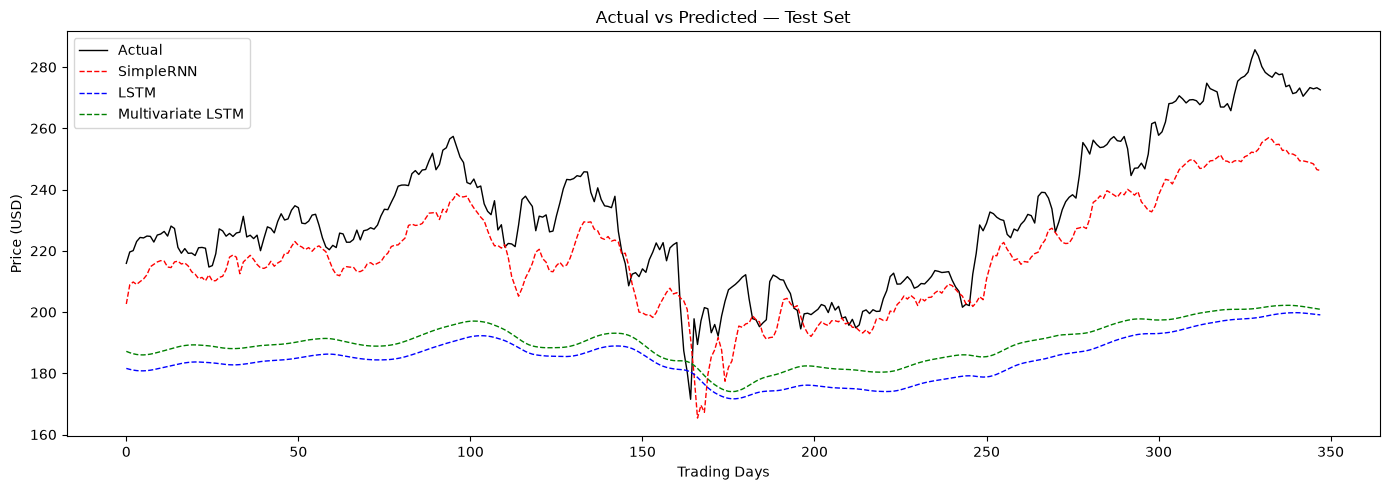

In [50]:
plt.figure(figsize=(14, 5))
plt.plot(y_actual, label='Actual',    color='black',  linewidth=1)
plt.plot(y_pred1,  label='SimpleRNN', color='red',    linewidth=1, linestyle='--')
plt.plot(y_pred2,  label='LSTM',      color='blue',   linewidth=1, linestyle='--')
plt.plot(y_pred3,  label='Multivariate LSTM', color='green', linewidth=1, linestyle='--')
plt.title('Actual vs Predicted — Test Set')
plt.xlabel('Trading Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

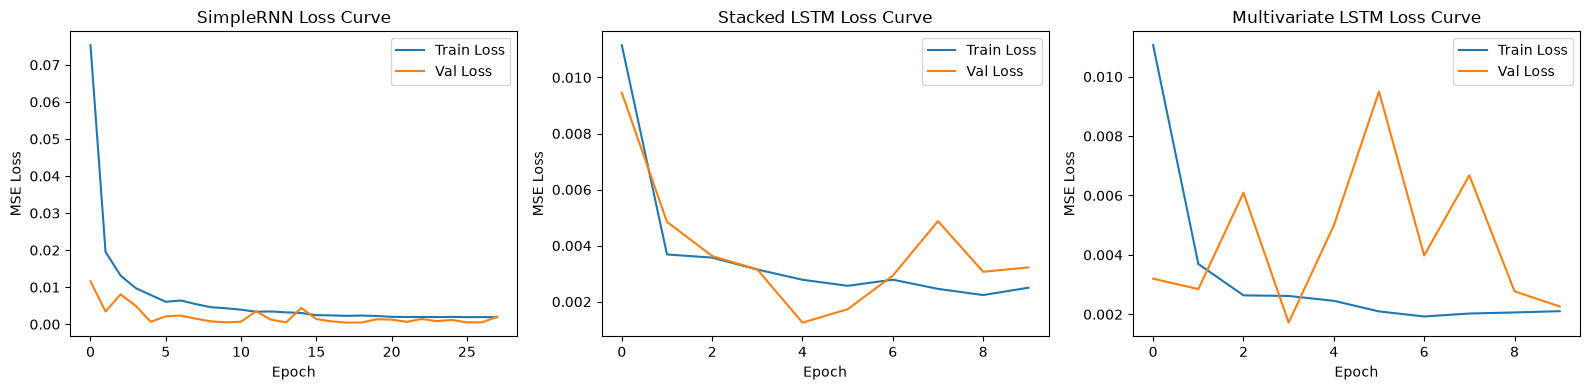

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, history, name in zip(axes,
                              [history1, history2, history3],
                              ['SimpleRNN', 'Stacked LSTM', 'Multivariate LSTM']):
    ax.plot(history.history['loss'],     label='Train Loss')
    ax.plot(history.history['val_loss'], label='Val Loss')
    ax.set_title(f'{name} Loss Curve')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()

plt.tight_layout()
plt.show()

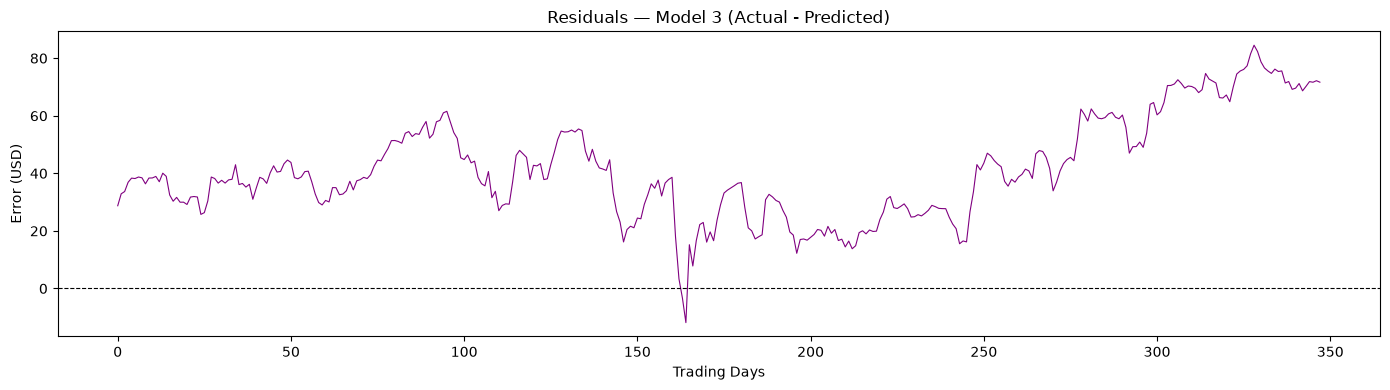

In [52]:
plt.figure(figsize=(14, 4))
plt.plot(y_actual - y_pred3, color='purple', linewidth=0.8)
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Residuals — Model 3 (Actual - Predicted)')
plt.xlabel('Trading Days')
plt.ylabel('Error (USD)')
plt.tight_layout()
plt.show()

In [54]:
import joblib

# Save model and scaler
model3.save('lstm_model.h5')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [56]:
# Save in new format
model1.save('model.keras')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']